In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
# Imports
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from src.feature_engineering import (
    process_bureau_data,
    DropHighMissingColumns,
    AddMissingIndicators,
    ApplicationFeatureEngineer,
    FrequencyEncoder,
    HighCorrelationFilter,
    BureauMergerAndImputer
)
from src.preprocessing import DynamicPreprocessingPipeline, ClusterSegmenterWrapper, evaluate_missingness_predictiveness, ClusterSegmenter

In [3]:
# Load Feature-Engineered Datasets
data_dir = Path("../data")
df_app = pd.read_csv(data_dir / "application_train.csv")
df_bureau = pd.read_csv(data_dir / "bureau.csv")

df_app_train, df_app_test, y_train, y_test = train_test_split(df_app.drop(columns=["TARGET"]), df_app["TARGET"], test_size=0.2, random_state=42)

In [4]:
# Initialize the Pipeline with the custom transformer
bur_pipeline = Pipeline([
    ("bureau_merger", BureauMergerAndImputer(df_bureau=df_bureau)),
])

# pipeline that merges the aggregated bureau dataframe with the application data
bur_pipeline.fit(df_app_train, y_train)

# merging & transforming the datasets via the pipeline
df_train = bur_pipeline.transform(df_app_train)
df_test = bur_pipeline.transform(df_app_test)

#repeating the feature engineering methods described in the 02_feature_engineering.ipynb notebook
fe_pipeline = Pipeline(
    steps=[
        ("drop_high_missing", DropHighMissingColumns(threshold=65.0)),
        ("add_missing_indicators", AddMissingIndicators(threshold=5.0)),
        ("feature_engineer", ApplicationFeatureEngineer()),
        ("remove_correlated_features", HighCorrelationFilter(threshold=0.95)),
        ("frequency_encoding", FrequencyEncoder(cols=["OCCUPATION_TYPE"]))
    ]
)

df_train_fe = fe_pipeline.fit_transform(df_train)
df_test_fe = fe_pipeline.transform(df_test)

In [5]:
education_categories = [
    "Lower secondary",
    "Secondary / secondary special",
    "Incomplete higher",
    "Higher education",
    "Academic degree",
]
ordinal_cols = ["NAME_EDUCATION_TYPE"]
ohe_cols = [
    "WALLSMATERIAL_MODE",
    "HOUSETYPE_MODE",
    "EMERGENCYSTATE_MODE",
    "NAME_TYPE_SUITE",
]
freq_cols = ["OCCUPATION_TYPE"]

## Checking the predictive power of the missing indicator columns ONLY

In [6]:
missing_cols = [c for c in df_train_fe.columns if c.endswith("_IS_MISSING")]
df_train_fe['TARGET'] = y_train.values
df_test_fe['TARGET'] = y_test.values

# this function extracts the 'IS_MISSING' columns and fits a logistic regression model to test the columns' effectiveness in predicting the target variable
evaluate_missingness_predictiveness(df_train_fe, missing_cols) 

Logistic Regression ROC-AUC (Missingness Indicators Only): 0.5737


(0.5737304273495002,
 LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))

A 0.5737 score shows moderate predictive power, and is still better than random guessing. Therefore, these columns will be included for the final modeling. 

In [7]:
# transforming the train and the test data categorical columns

pre_pipeline = Pipeline(
    steps=[
("preprocessor", DynamicPreprocessingPipeline(              # preprocessing categorical columns (one-hot encoding, ordinal, frequency encoding)
        education_categories=education_categories,
        ordinal_cols=ordinal_cols,
        ohe_cols=ohe_cols,
        freq_cols=freq_cols
    )),
    ]
)

df_train_pre = pre_pipeline.fit_transform(df_train_fe)
df_test_pre = pre_pipeline.transform(df_test_fe)

## Customer Segmentation using k-Means clustering

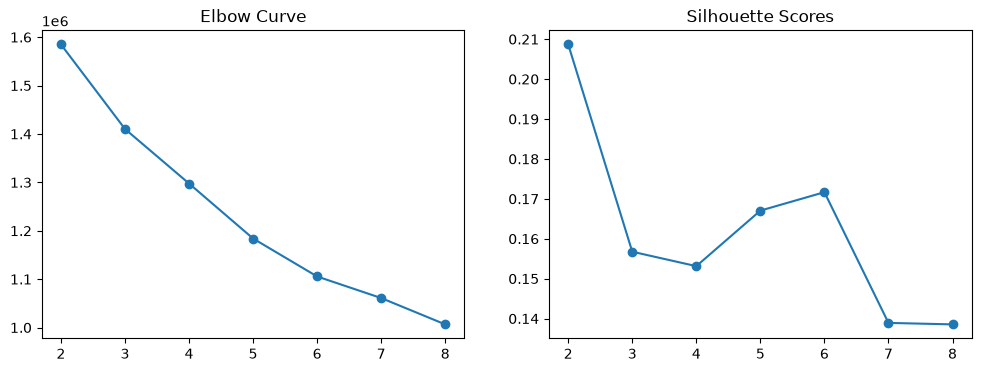

In [8]:
# Cluster Optimization (Elbow & Silhouette Analysis)
cluster_features = [
    "num__AMT_INCOME_TOTAL",
    "num__AMT_CREDIT",
    "num__CREDIT_INCOME_RATIO",
    "num__AGE",
    "num__EXT_SOURCE_MEAN",
    "num__num_bureau_records",
    "num__DAYS_EMPLOYED",
    "num__AMT_ANNUITY",
]

scaler = StandardScaler()
X_scaled_sample = scaler.fit_transform(df_train_pre[cluster_features]).astype("float32")

inertias, sil_scores = [], []
K = range(2, 9)

for k in K:
    km = MiniBatchKMeans(n_clusters=k, batch_size=4096, random_state=42, n_init=3)
    labels = km.fit_predict(X_scaled_sample)
    
    rng = np.random.default_rng(42)
    idx = rng.choice(len(X_scaled_sample), size=10000, replace=False)
    score = silhouette_score(X_scaled_sample[idx], labels[idx])
    
    inertias.append(km.inertia_)
    sil_scores.append(score)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(K, inertias, marker="o")
plt.title("Elbow Curve")
plt.subplot(1, 2, 2)
plt.plot(K, sil_scores, marker="o")
plt.title("Silhouette Scores")
plt.show()

### Clustering Evaluation

* **Optimal number of clusters: `k = 2`**

  * The Silhouette Score reaches its global maximum at **k = 2 (~0.209)**, indicating the best overall balance of within-cluster cohesion and between-cluster separation.
  * The sharp decline in silhouette scores for **k = 3 and k = 4** suggests that additional clusters introduce greater overlap and reduce cluster quality.

* **Elbow Method**

  * The largest reduction in inertia occurs when moving from **k = 2 to k = 3**, indicating that two clusters capture the primary structure in the data.
  * Beyond **k = 2**, the inertia declines more gradually without a distinct elbow, suggesting that additional clusters primarily subdivide existing groups rather than reveal meaningful new segments.

**Conclusion:** Both the Silhouette and Elbow analyses support **k = 2** as the most appropriate clustering solution for customer segmentation.


In [9]:
# Apply Customer Segmentation Transformer
segmenter = ClusterSegmenter(cluster_features=cluster_features, n_clusters=2) # the optimal number of clusters was manually inferred using the Elbow & Silhouette Analysis
df_X_train = segmenter.fit_transform(df_train_pre)
df_X_test = segmenter.transform(df_test_pre)

In [10]:
#print(df_X_train.head())
cluster_features_ext = cluster_features + ['customer_segment']
df_X_train[df_X_train['customer_segment'] == 0][cluster_features_ext].head(20)

,num__AMT_INCOME_TOTAL,num__AMT_CREDIT,num__CREDIT_INCOME_RATIO,num__AGE,num__EXT_SOURCE_MEAN,num__num_bureau_records,num__DAYS_EMPLOYED,num__AMT_ANNUITY,customer_segment
2,135000.0,776304.0,5.750400,63.597260,0.674805,4.0,-2157.0,25173.0,0
3,164133.0,900000.0,5.483358,29.323288,0.407186,8.0,-2530.0,36787.5,0
5,405000.0,675000.0,1.666667,45.810959,0.631027,13.0,-1482.0,30631.5,0
6,450000.0,2125953.0,4.724340,27.728767,0.534715,3.0,-1354.0,81108.0,0
7,180000.0,679500.0,3.775000,48.427397,0.463904,2.0,-2535.0,24201.0,0
9,252000.0,1762110.0,6.992500,53.027397,0.462509,9.0,-1731.0,48586.5,0
11,135000.0,760225.5,5.631300,30.610959,0.530172,5.0,-1127.0,30280.5,0
15,184500.0,1113840.0,6.037073,51.972603,0.697806,8.0,-4953.0,57001.5,0
18,237150.0,1260000.0,5.313093,31.347945,0.545270,1.0,-1187.0,33367.5,0
20,540000.0,1928304.0,3.570933,44.432877,0.676140,8.0,-1636.0,73449.0,0


In [11]:
df_X_train[df_X_train['customer_segment'] == 1][cluster_features_ext].head(20)

,num__AMT_INCOME_TOTAL,num__AMT_CREDIT,num__CREDIT_INCOME_RATIO,num__AGE,num__EXT_SOURCE_MEAN,num__num_bureau_records,num__DAYS_EMPLOYED,num__AMT_ANNUITY,customer_segment
0,171000.0,555273.0,3.247211,63.969863,0.482363,8.0,-1646.0,16366.5,1
1,157500.0,198085.5,1.257686,29.920548,0.443562,13.0,-117.0,23638.5,1
4,225000.0,533668.5,2.371860,43.282192,0.588001,8.0,-3520.0,21294.0,1
8,180000.0,270000.0,1.500000,45.391781,0.613161,6.0,-2155.0,13500.0,1
10,67500.0,225000.0,3.333333,30.838356,0.412359,7.0,-362.0,13725.0,1
12,225000.0,331632.0,1.473920,28.309589,0.398222,2.0,-3643.0,35316.0,1
13,157500.0,278613.0,1.768971,42.068493,0.490412,4.0,-167.0,27684.0,1
14,90000.0,432000.0,4.800000,43.276712,0.658135,3.0,-465.0,21141.0,1
16,112500.0,337500.0,3.000000,48.884932,0.494609,1.0,-1405.0,16875.0,1
17,157500.0,247500.0,1.571429,35.936986,0.511116,1.0,-1649.0,26118.0,1


# Cluster Analysis Summary

## Cluster 0 — Higher-Leverage / Larger-Loan Applicants

### Key Characteristics
* **Credit & Income Ratio:** Higher credit amounts, often substantially larger relative to income, with credit-to-income ratios frequently around **4.7–6.0+**, indicating greater borrowing exposure.
* **Repayment:** A tendency toward higher monthly annuity payments, reflecting the larger loan amounts.
* **Demographics:** A mix of ages, including both younger and older applicants.
* **External Scores:** `EXT_SOURCE` scores vary considerably, indicating that external credit quality is not the primary defining characteristic of this cluster.

### Applicant Profile
Cluster 0 represents **higher-leverage applicants** seeking relatively large amounts of credit compared with their income. Their elevated `CREDIT_INCOME_RATIO` and larger `AMT_CREDIT` suggest greater debt exposure and potentially higher repayment burden. The combination of large loan amounts and, in some cases, fewer bureau records may warrant additional scrutiny during credit assessment.

---

## Cluster 1 — Lower-Leverage / More Established Applicants

### Key Characteristics
* **Credit & Income Ratio:** Lower credit-to-income ratios, with many observations between approximately **1.2 and 3.8**, accompanied by smaller credit amounts relative to Cluster 0.
* **Repayment:** More moderate annuity payments, consistent with smaller borrowing requirements.
* **Demographics:** A broad age range, indicating that age is not the primary distinguishing factor.
* **External Scores:** `EXT_SOURCE` scores are generally moderate, although there is considerable variation.

### Applicant Profile
Cluster 1 represents **lower-leverage applicants** with more moderate borrowing requirements relative to their income. Their lower `CREDIT_INCOME_RATIO`, smaller loan amounts, and generally more established bureau histories indicate comparatively lower credit exposure and potentially more predictable borrowing behavior.

In [12]:
# Adding back the target variable and the ID columns before saving them

df_X_train["TARGET"] = df_train_fe["TARGET"].values
df_X_test["TARGET"] = df_test_fe["TARGET"].values

df_X_train.insert(0, "SK_ID_CURR", df_train_fe["SK_ID_CURR"].values)
df_X_test.insert(0, "SK_ID_CURR", df_test_fe["SK_ID_CURR"].values)


df_X_train.to_csv(data_dir / "X_train_preprocessed.csv", index=False)
df_X_test.to_csv(data_dir / "X_test_preprocessed.csv", index=False)

#df_X_train.to_csv(os.path.join(data_dir, "X_train_preprocessed.csv"), index=False)
#df_X_test.to_csv(os.path.join(data_dir, "X_test_preprocessed.csv"), index=False)